# Data Preprocessing dan Exploratory Data Analysis

Notebook ini digunakan untuk melakukan preprocessing data dan exploratory data analysis (EDA) pada data harga saham sektor batubara Indonesia periode 2004–2024.

Tahapan analisis meliputi:
- pembentukan dataset time series
- perhitungan log return
- visualisasi harga historis
- dekomposisi time series
- uji stasioneritas
- analisis distribusi data
- identifikasi pola autokorelasi menggunakan ACF dan PACF

Output dari notebook ini digunakan sebagai dasar pemodelan ARIMA, LSTM, dan Hybrid ARIMA-LSTM pada tahap berikutnya.

## 1. Import Library

Mengimpor seluruh library yang dibutuhkan untuk:
- manipulasi data
- visualisasi
- analisis statistik
- time series analysis
- uji stasioneritas

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import os

In [2]:
%matplotlib inline

## 2. Konfigurasi Visualisasi Publication-Ready

Mengatur:
- font jurnal
- resolusi figure
- layout visualisasi
- style publication-ready
- color palette konsisten

In [3]:
FONT = "DejaVu Serif"

plt.rcParams.update({
    "font.family":       FONT,
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "savefig.pad_inches": 0.05,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.linestyle":    "--",
    "grid.linewidth":    0.6,
})

C = {
    "navy":     "#1B3A6B",
    "blue":     "#2471A3",
    "red":      "#C0392B",
    "orange":   "#D35400",
    "green":    "#1E8449",
    "gray":     "#7F8C8D",
    "lblue":    "#AED6F1",
    "lred":     "#F5B7B1",
    "lgreen":   "#A9DFBF",
}

DIR_FIG  = "/home/claude/jutif/figures"
DIR_DATA = "/home/claude/jutif/data"

os.makedirs(DIR_FIG,  exist_ok=True)
os.makedirs(DIR_DATA, exist_ok=True)

## 3. Pembangkitan dan Persiapan Dataset

Membuat dataset representatif saham batubara IDX:
- ADRO
- PTBA
- INDY
- PTBA

Dataset mencakup:
- harga saham historis
- simulasi volatilitas
- booming batu bara
- efek COVID-19
- log return harian

In [4]:
DIR_DATA = "."
DIR_FIG = "figures"
os.makedirs(DIR_DATA, exist_ok=True)
os.makedirs(DIR_FIG, exist_ok=True)

# Load real Yahoo Finance dataset 2004-2024
csv_path = "data/harga_saham_yfinance.csv"
if not os.path.exists(csv_path):
    csv_path = "data/harga_saham_yfinance.csv"

df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
ticker_list = ["ADRO", "PTBA", "INDY", "ITMG"]

for col in ticker_list:
    if f"ret_{col}" not in df.columns:
        df[f"ret_{col}"] = np.log(df[col] / df[col].shift(1))

print("Loaded dataset:", csv_path)
print(df.head())
print("Shape:", df.shape)


Loaded dataset: data/harga_saham_yfinance.csv
                  ADRO         INDY         ITMG       PTBA  ret_ADRO  \
Date                                                                    
2004-01-01  325.636292  1858.861938  2791.716553  31.526564       NaN   
2004-01-02  325.636292  1858.861938  2791.716553  34.228844       0.0   
2004-01-05  325.636292  1858.861938  2791.716553  33.328083       0.0   
2004-01-06  325.636292  1858.861938  2791.716553  32.427326       0.0   
2004-01-07  325.636292  1858.861938  2791.716553  31.526564       0.0   

            ret_PTBA  ret_INDY  ret_ITMG  
Date                                      
2004-01-01       NaN       NaN       NaN  
2004-01-02  0.082238       0.0       0.0  
2004-01-05 -0.026668       0.0       0.0  
2004-01-06 -0.027399       0.0       0.0  
2004-01-07 -0.028171       0.0       0.0  
Shape: (5199, 8)


In [5]:
df.to_csv("data/harga_saham_yfinance.csv")
df

,ADRO,INDY,ITMG,PTBA,ret_ADRO,ret_PTBA,ret_INDY,ret_ITMG
Date,,,,,,,,
2004-01-01,325.636292,1858.861938,2791.716553,31.526564,NaN,NaN,NaN,NaN
2004-01-02,325.636292,1858.861938,2791.716553,34.228844,0.000000,0.082238,0.000000,0.000000
2004-01-05,325.636292,1858.861938,2791.716553,33.328083,0.000000,-0.026668,0.000000,0.000000
2004-01-06,325.636292,1858.861938,2791.716553,32.427326,0.000000,-0.027399,0.000000,0.000000
2004-01-07,325.636292,1858.861938,2791.716553,31.526564,0.000000,-0.028171,0.000000,0.000000
...,...,...,...,...,...,...,...,...
2024-12-20,1984.888184,1313.932617,21596.765625,2195.736816,0.003929,0.003868,-0.011300,-0.030861
2024-12-23,1977.104370,1343.794678,21702.529297,2195.736816,-0.003929,0.000000,0.022473,0.004885
2024-12-24,1953.752686,1403.518799,21406.392578,2195.736816,-0.011881,0.000000,0.043485,-0.013739


## 4. Visualisasi Harga Historis Saham

- historical closing price
- tren jangka panjang
- volatilitas saham
- event ekonomi penting
- dampak COVID-19
- booming batu bara
- kebijakan DMO pemerintah

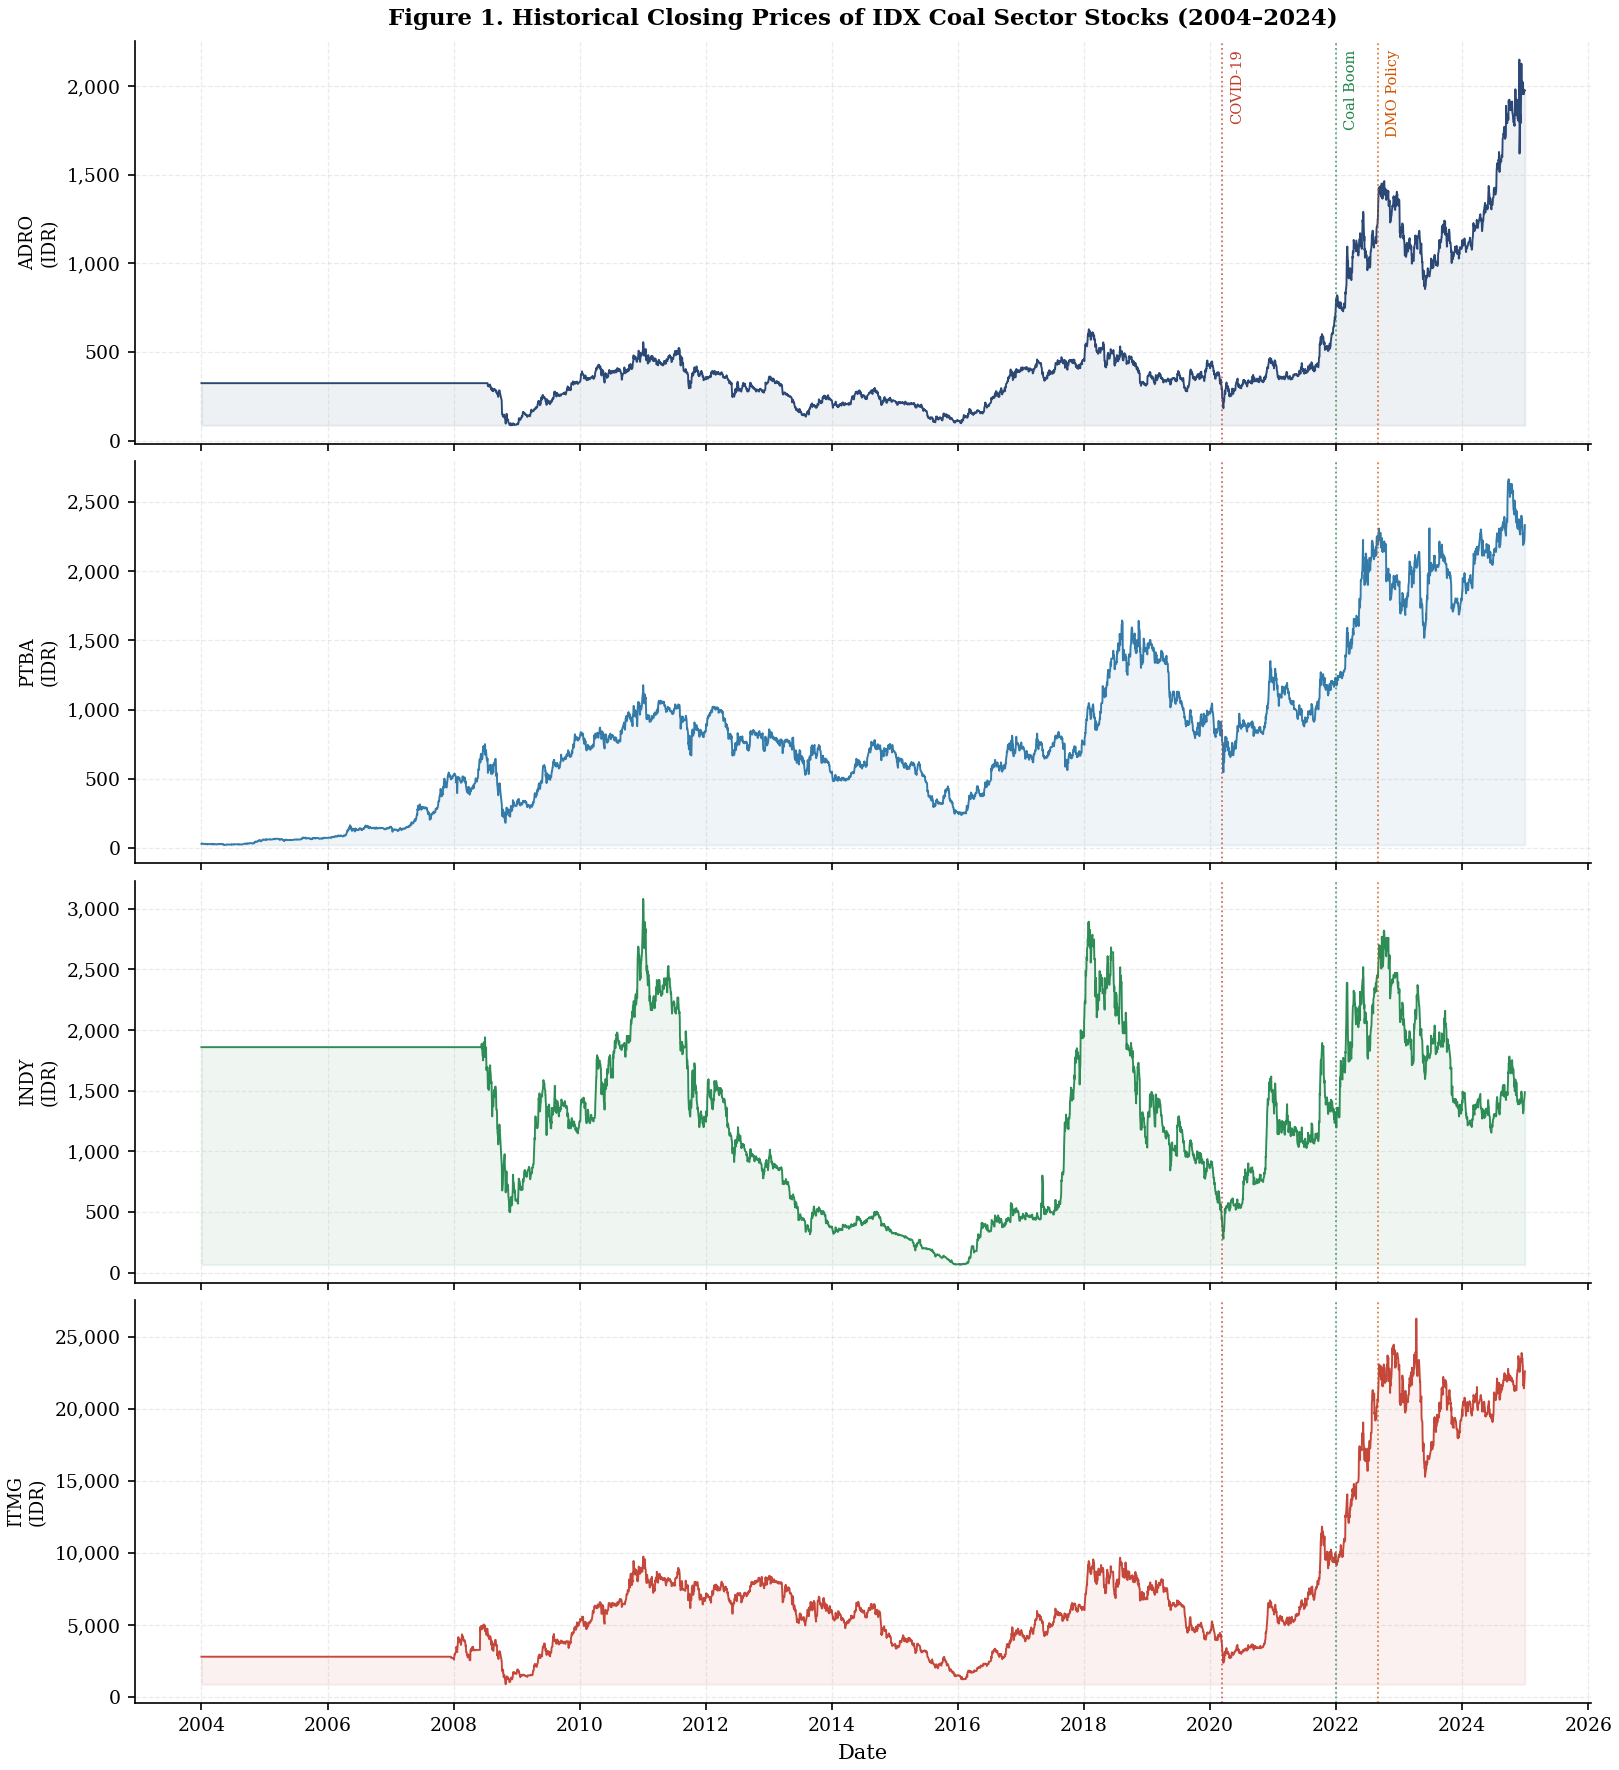

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True)

warna_saham = [
    C["navy"],
    C["blue"],
    C["green"],
    C["red"],
    C["orange"]
]

ticker_list = ["ADRO", "PTBA", "INDY", "ITMG"]

event_covid  = pd.Timestamp("2020-03-11")
event_boom   = pd.Timestamp("2022-01-01")
event_permen = pd.Timestamp("2022-09-01")

for i, (ax, ticker, warna) in enumerate(zip(axes, ticker_list, warna_saham)):

    ax.plot(df.index, df[ticker],
            color=warna,
            lw=0.9,
            alpha=0.92,
            label=ticker)

    ax.fill_between(df.index,
                    df[ticker].min(),
                    df[ticker],
                    alpha=0.07,
                    color=warna)

    ax.set_ylabel(f"{ticker}\n(IDR)",
                  fontsize=8.5,
                  labelpad=4)

    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda x, _: f"{x:,.0f}")
    )

    for ev, label, ev_warna in [
        (event_covid,  "COVID-19", "#C0392B"),
        (event_boom,   "Coal Boom", "#1E8449"),
        (event_permen, "DMO Policy", "#D35400"),
    ]:

        ax.axvline(ev,
                   color=ev_warna,
                   lw=0.85,
                   ls=":",
                   alpha=0.75)

        if i == 0:
            ax.annotate(label,
                        xy=(ev, ax.get_ylim()[1]),
                        fontsize=7,
                        color=ev_warna,
                        rotation=90,
                        xytext=(4, -4),
                        textcoords="offset points",
                        va="top")

axes[0].set_title(
    "Figure 1. Historical Closing Prices of IDX Coal Sector Stocks (2004–2024)",
    fontsize=11,
    fontweight="bold",
    pad=8
)

axes[-1].set_xlabel("Date", fontsize=10)

axes[-1].xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

axes[-1].xaxis.set_major_locator(
    mdates.YearLocator(2)
)

plt.tight_layout(h_pad=0.4)

fig.savefig(f"{DIR_FIG}/fig01_harga_historis.png", dpi=300)

plt.show()

## 5. Dekomposisi Time Series

- memisahkan komponen trend
- seasonal
- residual
- memahami pola time series
- justifikasi pemodelan forecasting

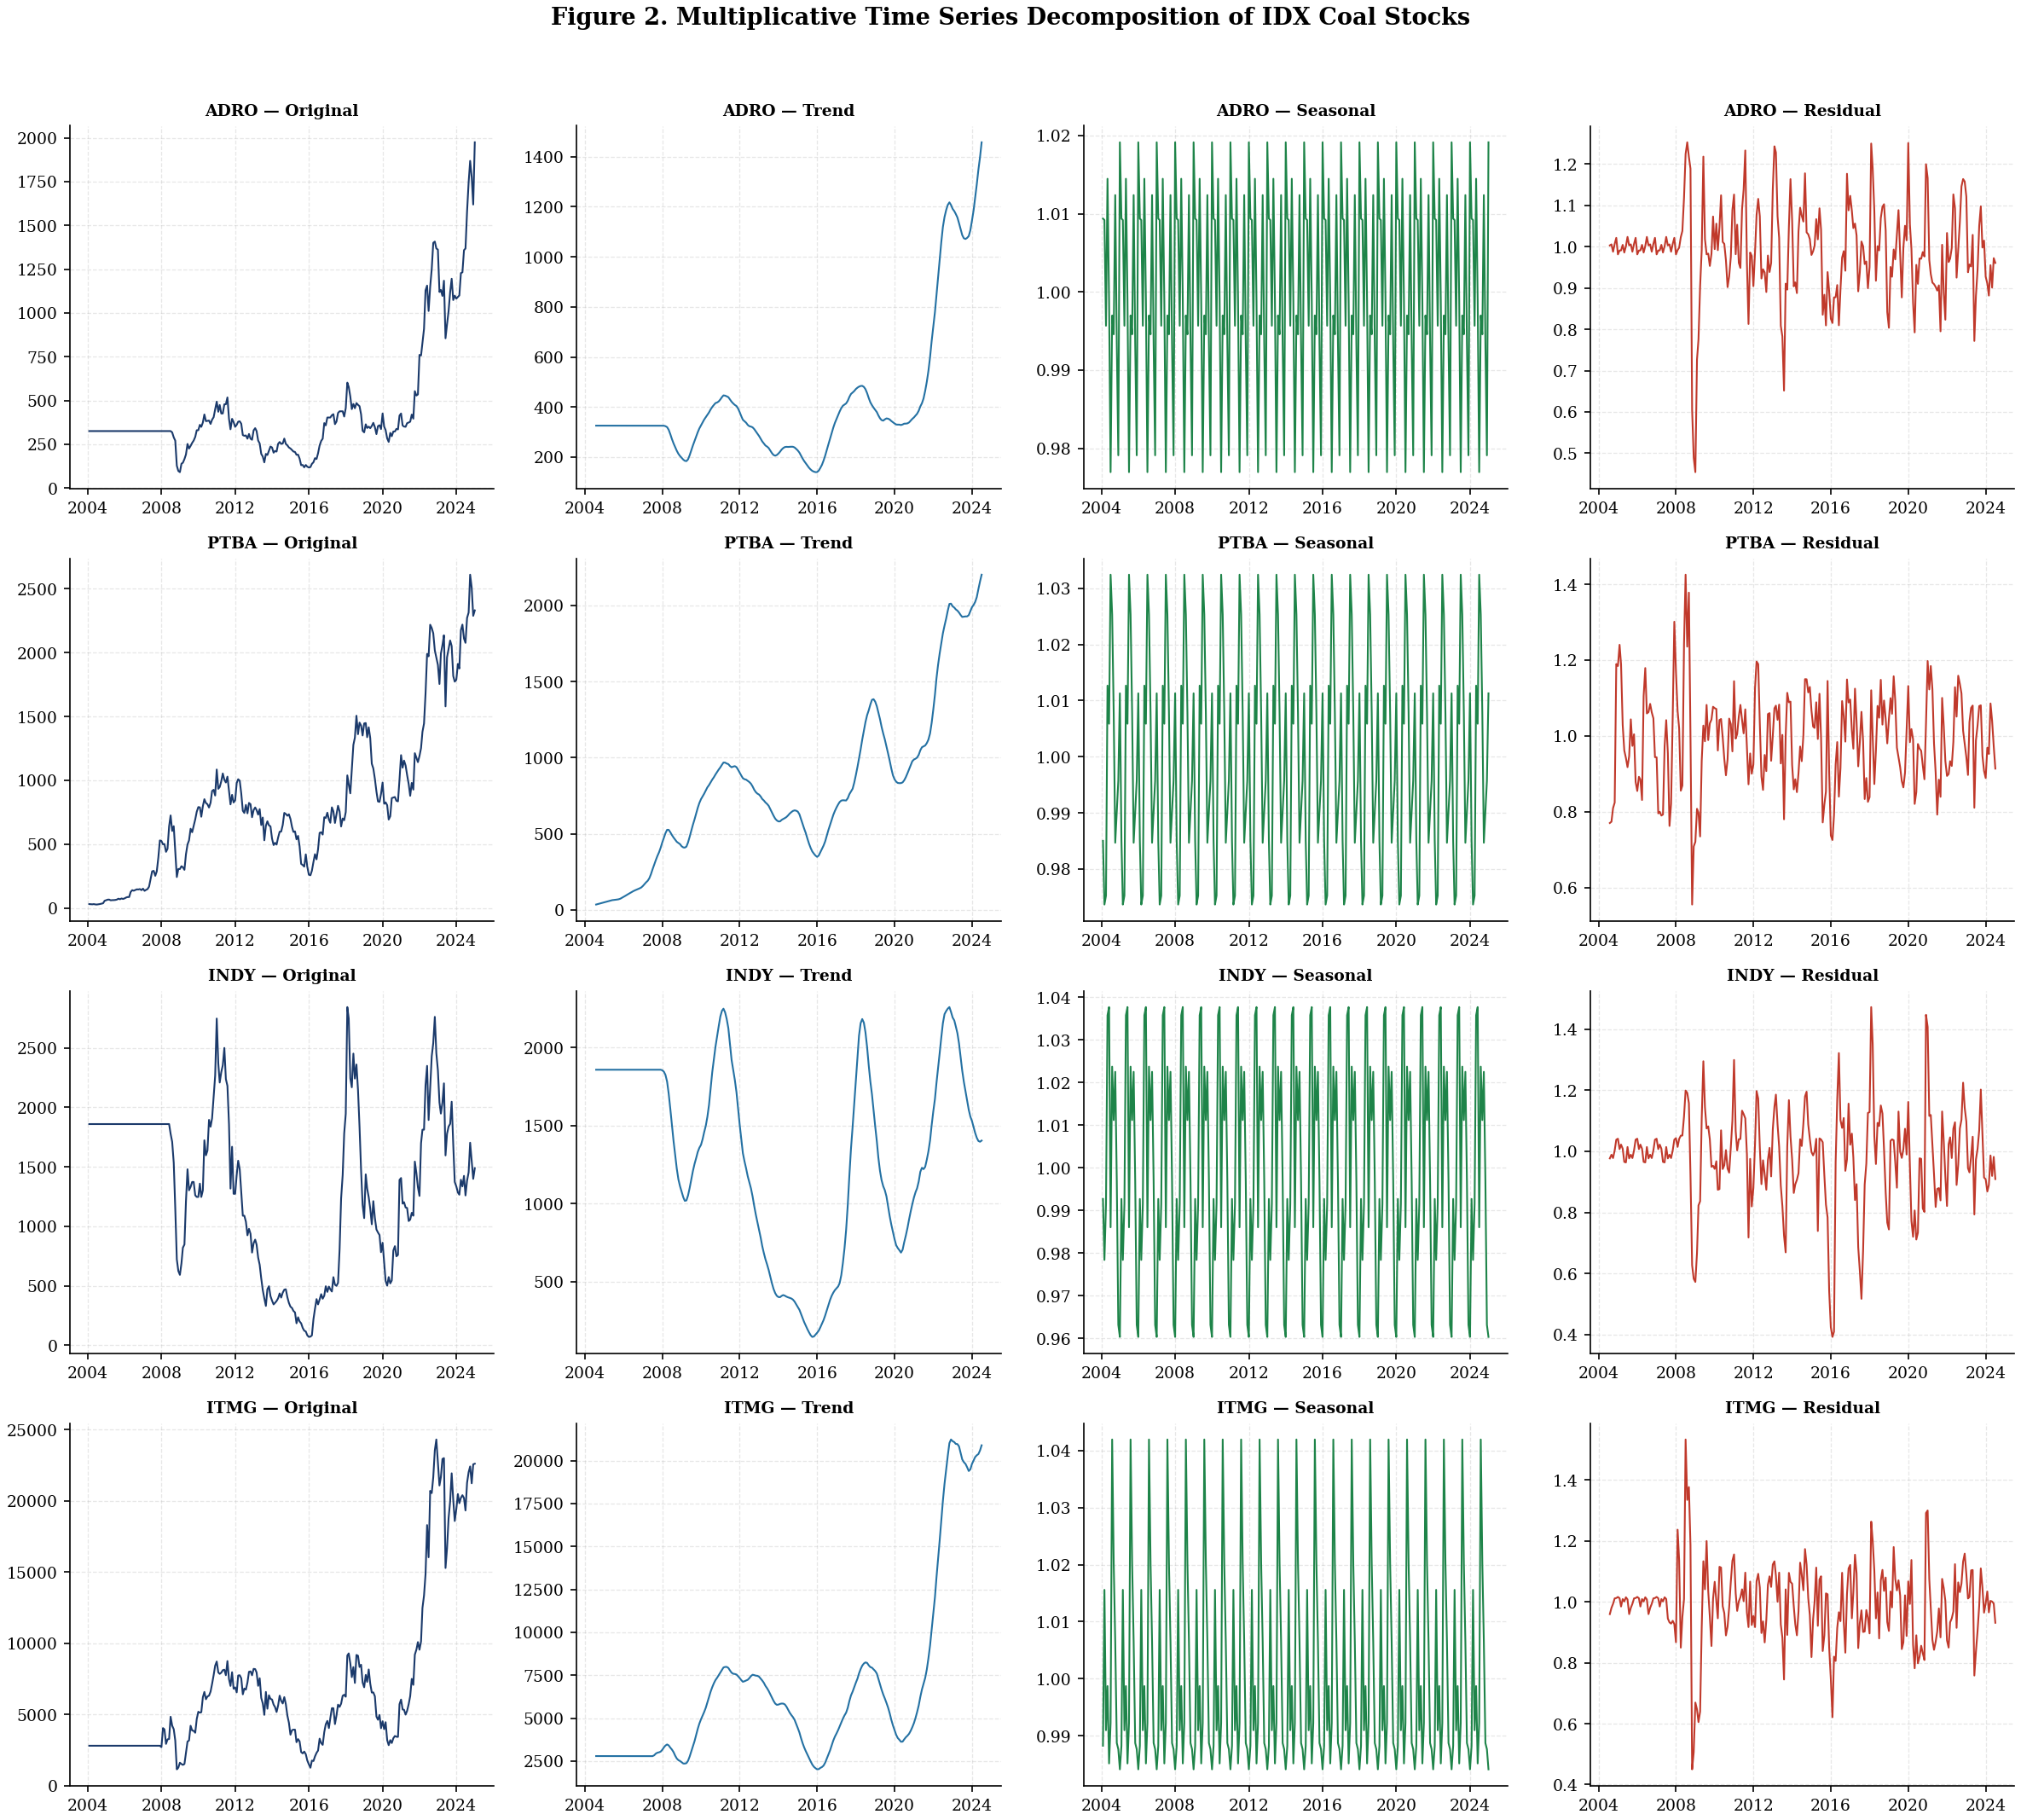

In [7]:
ticker_list = ["ADRO", "PTBA", "INDY", "ITMG"]

fig, axes = plt.subplots(
    len(ticker_list),
    4,
    figsize=(16, 14),
    sharex=False
)

for i, ticker in enumerate(ticker_list):

    seri_bulanan = df[ticker].resample("ME").last().dropna()

    dekomposisi = seasonal_decompose(
        seri_bulanan,
        model="multiplicative",
        period=12
    )

    komponen = [
        ("Original",  seri_bulanan,          C["navy"]),
        ("Trend",     dekomposisi.trend,     C["blue"]),
        ("Seasonal",  dekomposisi.seasonal,  C["green"]),
        ("Residual",  dekomposisi.resid,     C["red"]),
    ]

    for j, (label, data, warna) in enumerate(komponen):

        ax = axes[i, j]

        ax.plot(
            data.index,
            data,
            color=warna,
            lw=1
        )

        ax.set_title(
            f"{ticker} — {label}",
            fontsize=9,
            fontweight="bold"
        )

        ax.grid(alpha=0.3)

fig.suptitle(
    "Figure 2. Multiplicative Time Series Decomposition of IDX Coal Stocks",
    fontsize=13,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

fig.savefig(
    f"{DIR_FIG}/fig02_dekomposisi_semua_emiten.png",
    dpi=300
)

plt.show()

## 6. Persiapan Analisis Stasioneritas

Menyiapkan:
- original series
- first difference
- log return

Untuk:
- uji ADF
- identifikasi stationarity
- penentuan differencing ARIMA

In [8]:
ticker_list = ["ADRO", "PTBA", "INDY", "ITMG"]

data_stationarity = {}

for ticker in ticker_list:

    seri_level = df[ticker].dropna()

    seri_diff1 = seri_level.diff().dropna()

    seri_logret = np.log(
        seri_level / seri_level.shift(1)
    ).dropna()

    data_stationarity[ticker] = {
        "level": seri_level,
        "diff1": seri_diff1,
        "logret": seri_logret
    }

def adf_label(series):

    res  = adfuller(series, autolag="AIC")

    stat = res[1] < 0.05

    return (
        f"ADF: {res[0]:.3f}  p={res[1]:.4f}\n"
        f"{'Stationary ✔' if stat else 'Non-Stationary ✗'}"
    ), stat

## 7. Analisis Stasioneritas

- membandingkan level data
- first difference
- log return
- distribusi data
- skewness dan kurtosis
- validasi stasioneritas

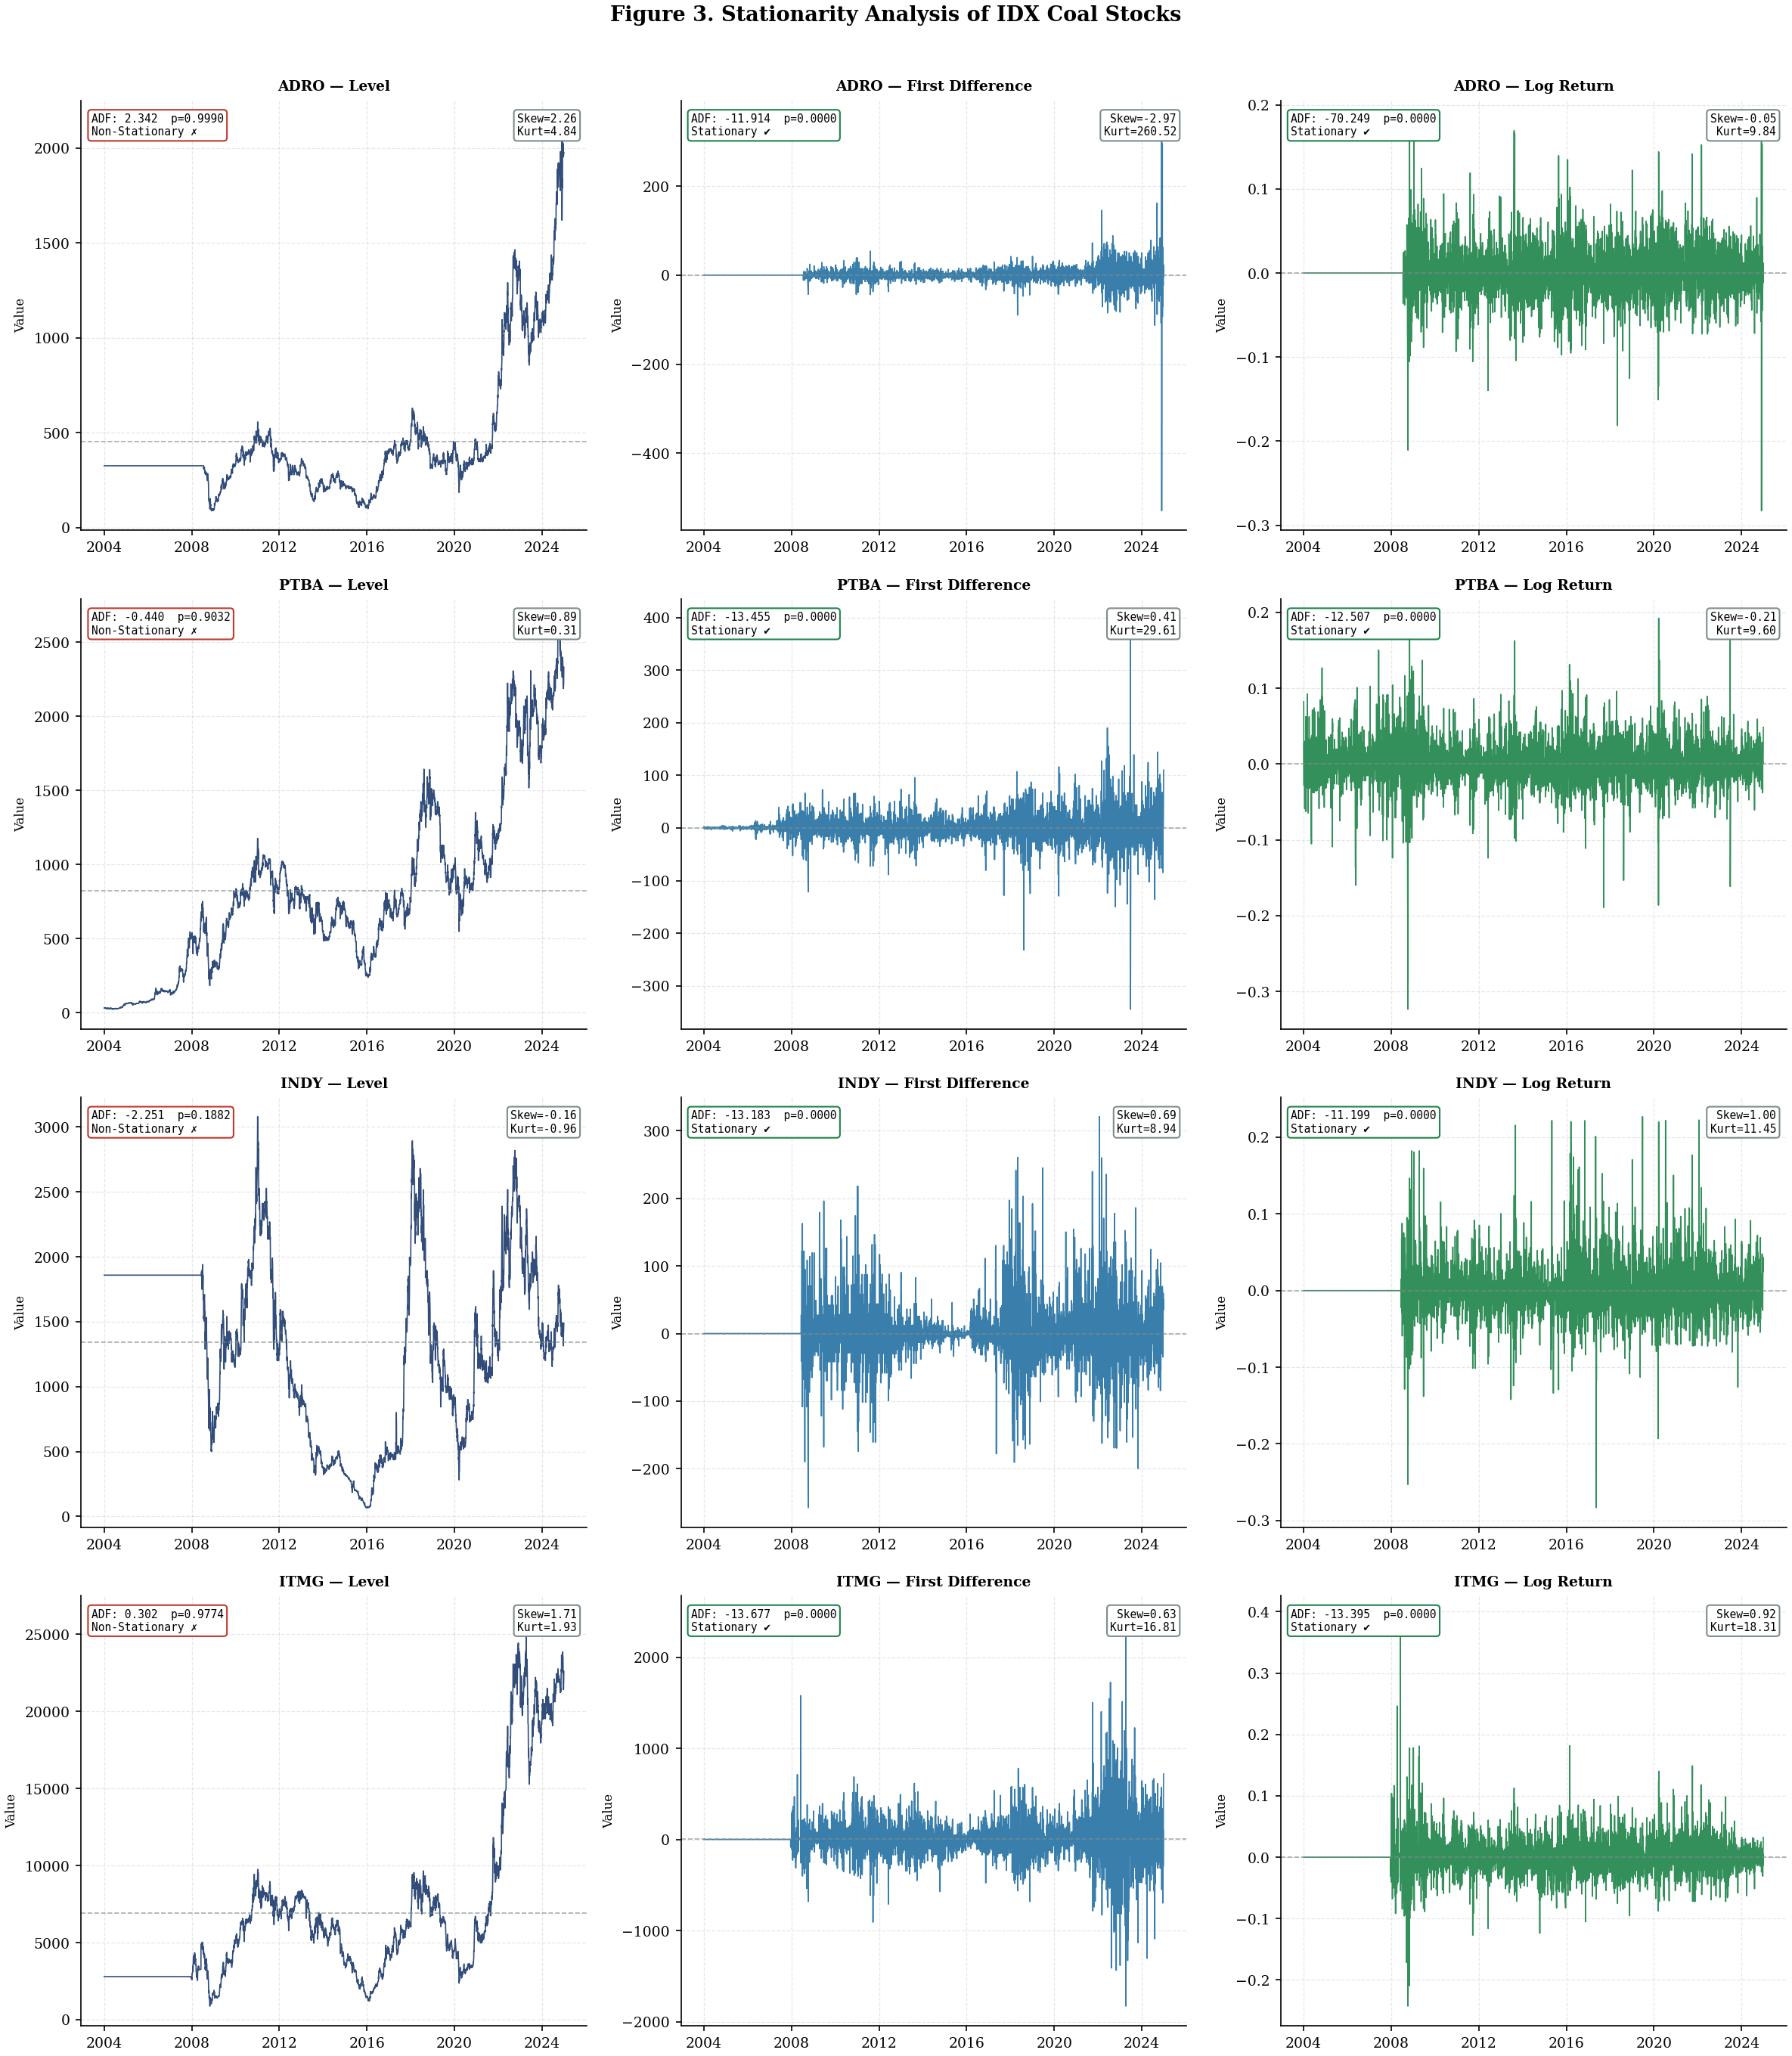

In [9]:
ticker_list = ["ADRO", "PTBA", "INDY", "ITMG"]

fig, axes = plt.subplots(
    len(ticker_list),
    3,
    figsize=(16, 18)
)

for row, ticker in enumerate(ticker_list):

    seri_level = df[ticker].dropna()

    seri_diff1 = seri_level.diff().dropna()

    seri_logret = np.log(
        seri_level / seri_level.shift(1)
    ).dropna()

    panel_data = [
        (seri_level,  "Level"),
        (seri_diff1, "First Difference"),
        (seri_logret, "Log Return"),
    ]

    warna_panel = [
        C["navy"],
        C["blue"],
        C["green"]
    ]

    for col, ((seri, judul), warna) in enumerate(
        zip(panel_data, warna_panel)
    ):

        ax = axes[row, col]

        ax.plot(
            seri.index,
            seri.values,
            color=warna,
            lw=0.8,
            alpha=0.9
        )

        ax.axhline(
            seri.mean(),
            color=C["gray"],
            lw=0.8,
            ls="--",
            alpha=0.7
        )

        label_adf, is_stat = adf_label(seri)

        border_color = (
            C["green"]
            if is_stat
            else C["red"]
        )

        ax.text(
            0.02,
            0.97,
            label_adf,
            transform=ax.transAxes,
            fontsize=7,
            va="top",
            family="monospace",
            bbox=dict(
                boxstyle="round,pad=0.3",
                fc="white",
                ec=border_color,
                lw=1
            )
        )

        sk = stats.skew(seri)

        kur = stats.kurtosis(
            seri,
            fisher=True
        )

        ax.text(
            0.98,
            0.97,
            f"Skew={sk:.2f}\nKurt={kur:.2f}",
            transform=ax.transAxes,
            fontsize=7,
            va="top",
            ha="right",
            family="monospace",
            bbox=dict(
                boxstyle="round,pad=0.3",
                fc="white",
                ec=C["gray"]
            )
        )

        ax.set_title(
            f"{ticker} — {judul}",
            fontsize=9,
            fontweight="bold"
        )

        ax.set_ylabel(
            "Value",
            fontsize=8
        )

        ax.grid(alpha=0.3)

fig.suptitle(
    "Figure 3. Stationarity Analysis of IDX Coal Stocks",
    fontsize=13,
    fontweight="bold",
    y=1.01
)

plt.tight_layout(
    h_pad=1.5,
    w_pad=1.0
)

fig.savefig(
    f"{DIR_FIG}/fig03_stasioneritas_semua_emiten.png",
    dpi=300
)

plt.show()

## 8. Analisis ACF dan PACF

- identifikasi orde ARIMA
- menentukan kandidat parameter p dan q
- melihat autokorelasi time series
- analisis partial autocorrelation

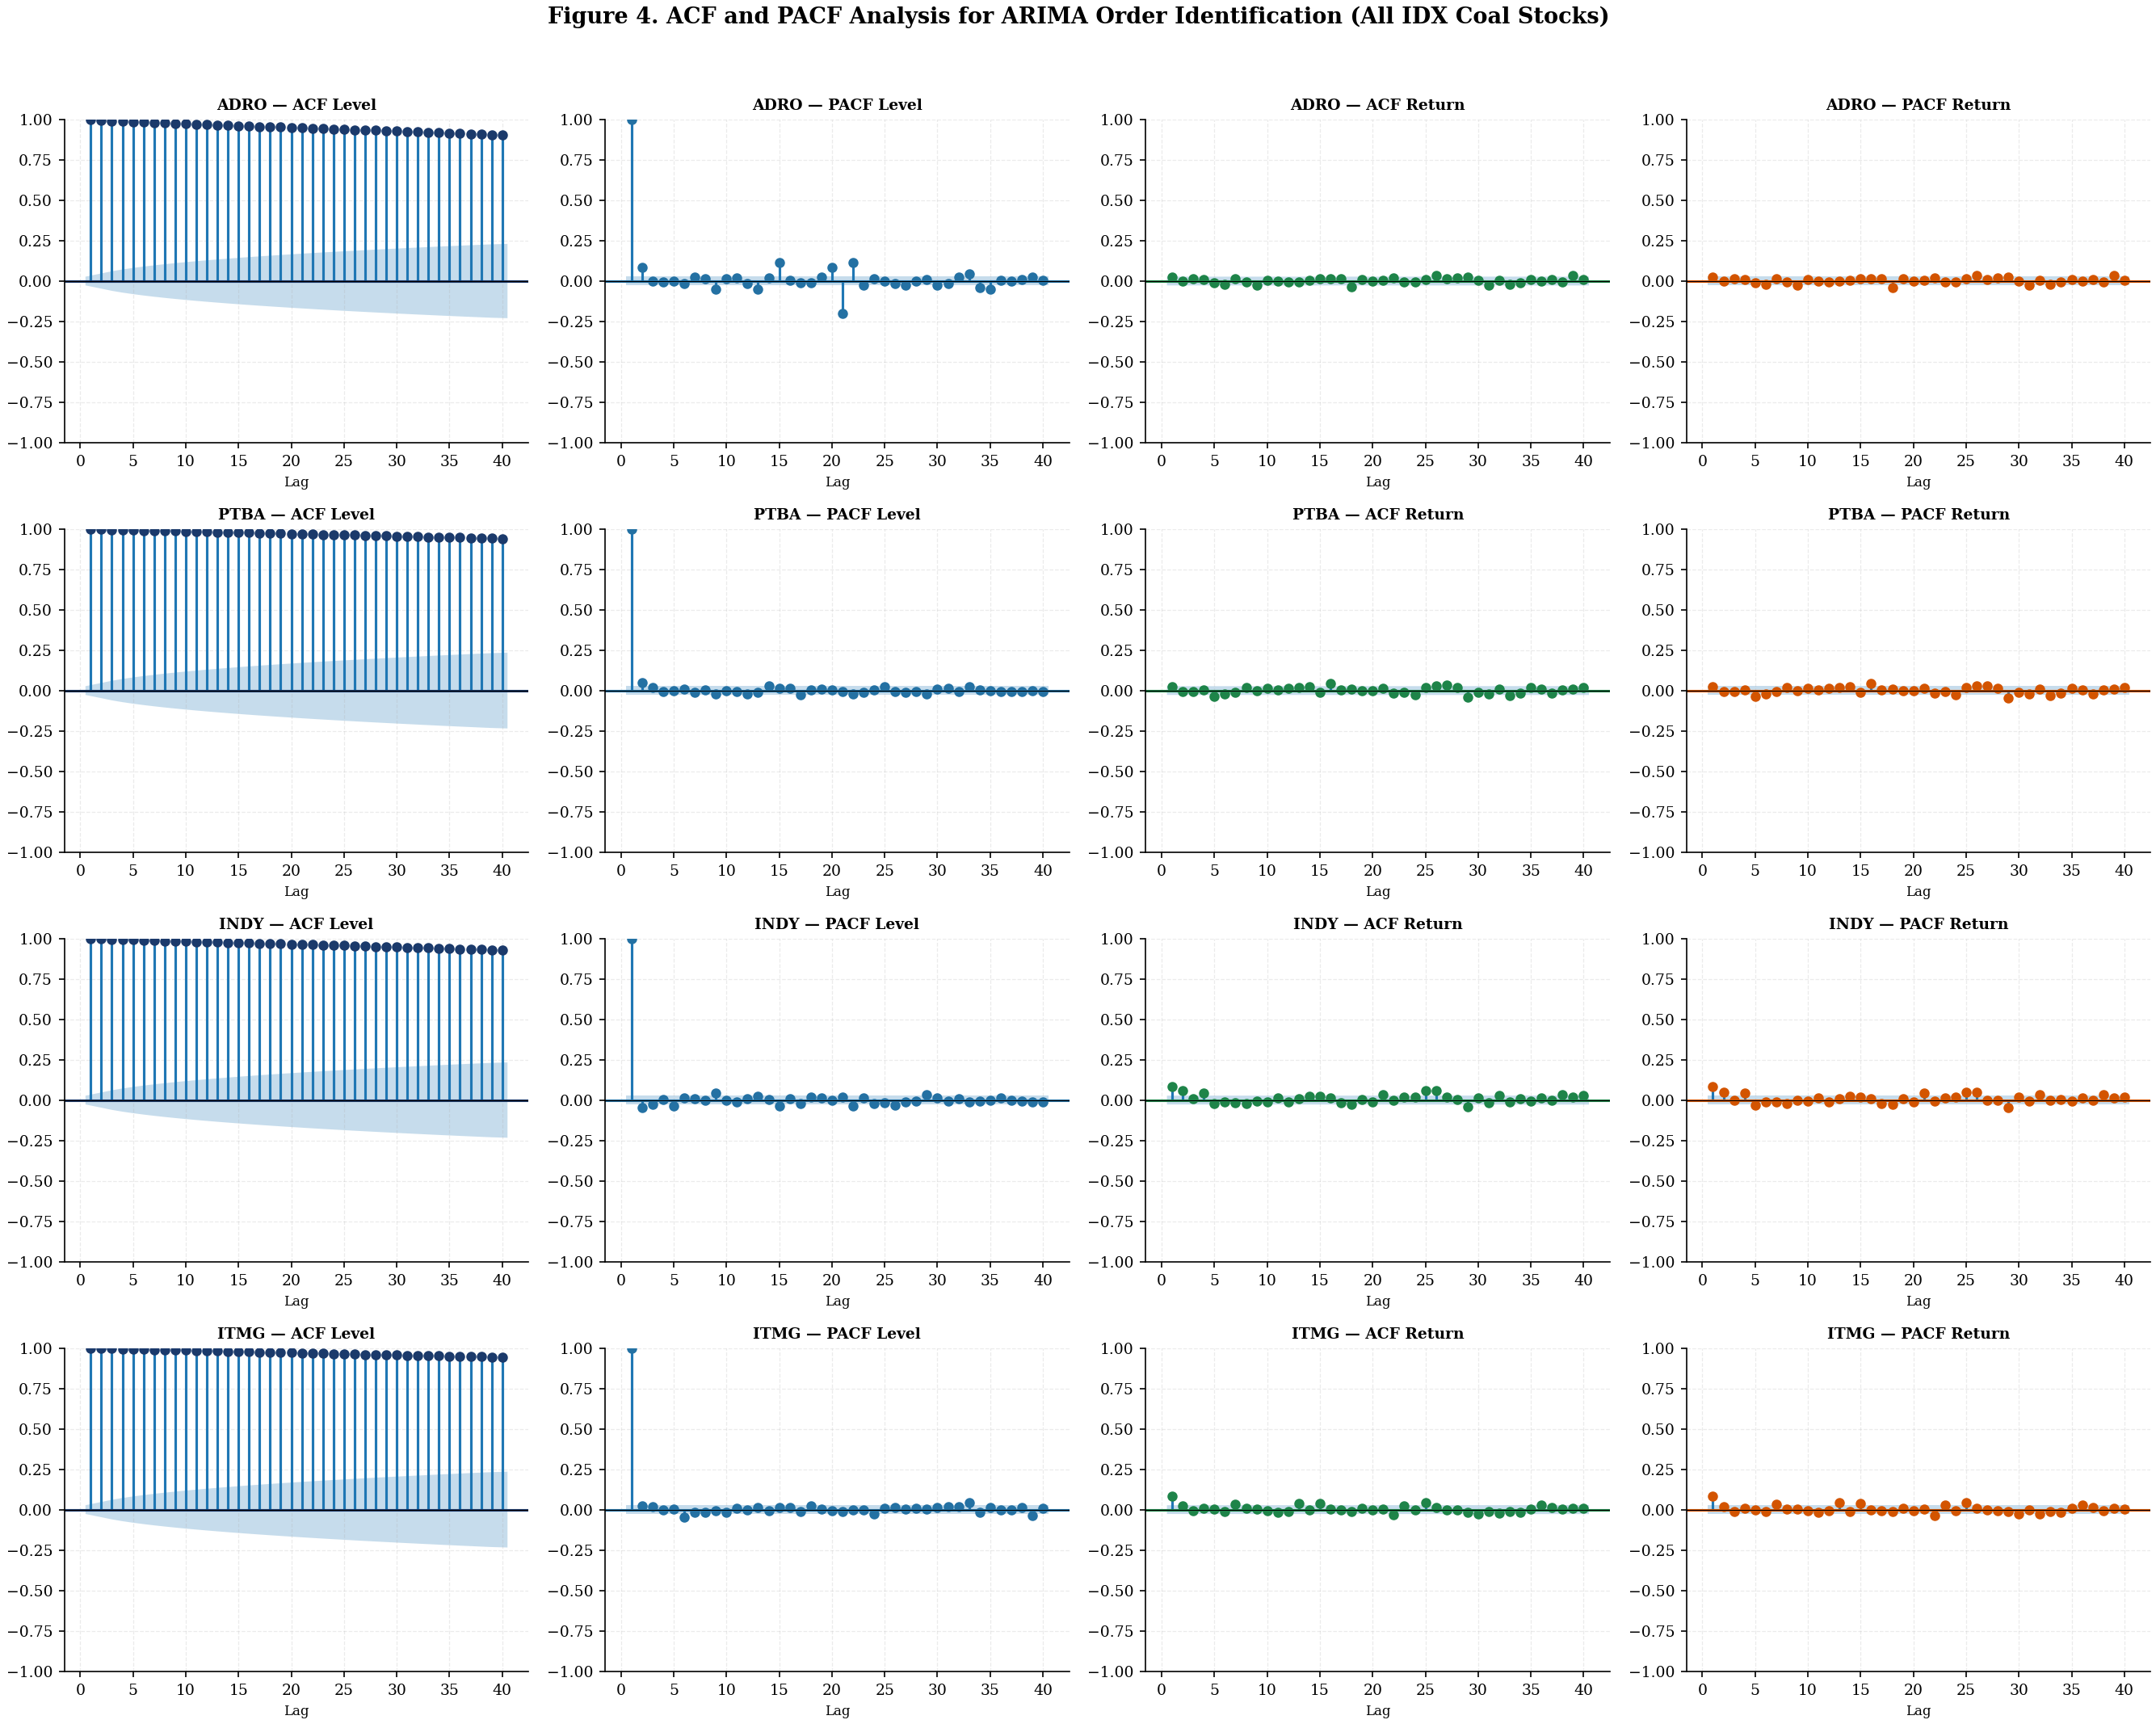

In [10]:
ticker_list = ["ADRO", "PTBA", "INDY", "ITMG"]

fig, axes = plt.subplots(
    len(ticker_list),
    4,
    figsize=(18, 14)
)

for i, ticker in enumerate(ticker_list):

    seri_level = df[ticker].dropna()

    seri_logret = np.log(
        seri_level / seri_level.shift(1)
    ).dropna()

    # ACF Level
    plot_acf(
        seri_level,
        ax=axes[i, 0],
        lags=40,
        color=C["navy"],
        alpha=0.05,
        zero=False
    )
    axes[i, 0].set_title(f"{ticker} — ACF Level", fontsize=9, fontweight="bold")

    # PACF Level
    plot_pacf(
        seri_level,
        ax=axes[i, 1],
        lags=40,
        color=C["blue"],
        alpha=0.05,
        zero=False,
        method="ywm"
    )
    axes[i, 1].set_title(f"{ticker} — PACF Level", fontsize=9, fontweight="bold")

    # ACF Log Return
    plot_acf(
        seri_logret,
        ax=axes[i, 2],
        lags=40,
        color=C["green"],
        alpha=0.05,
        zero=False
    )
    axes[i, 2].set_title(f"{ticker} — ACF Return", fontsize=9, fontweight="bold")

    # PACF Log Return
    plot_pacf(
        seri_logret,
        ax=axes[i, 3],
        lags=40,
        color=C["orange"],
        alpha=0.05,
        zero=False,
        method="ywm"
    )
    axes[i, 3].set_title(f"{ticker} — PACF Return", fontsize=9, fontweight="bold")

    for ax in axes[i]:
        ax.axhline(0, color="black", lw=0.5)
        ax.set_xlabel("Lag", fontsize=8)

fig.suptitle(
    "Figure 4. ACF and PACF Analysis for ARIMA Order Identification (All IDX Coal Stocks)",
    fontsize=13,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

fig.savefig(
    f"{DIR_FIG}/fig04_acf_pacf_semua_emiten.png",
    dpi=300
)

plt.show()

## 9. Heatmap Korelasi Antar Emiten

Visualisasi heatmap digunakan untuk melihat hubungan korelasi return antar saham batubara IDX. Korelasi yang tinggi menunjukkan adanya pergerakan yang cenderung searah antar emiten dalam sektor yang sama.

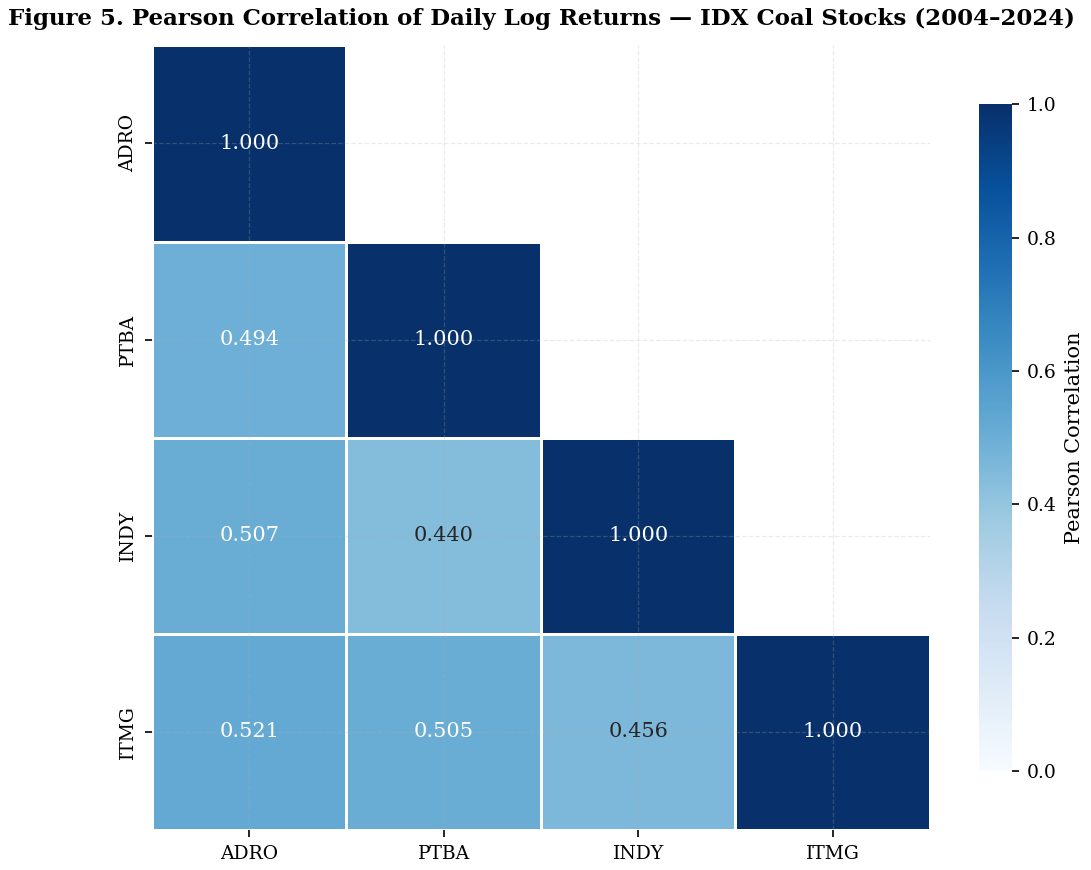

In [11]:
ret_cols = [f"ret_{t}" for t in ticker_list]

corr_mat = df[ret_cols].dropna().corr()

corr_mat.index   = ticker_list
corr_mat.columns = ticker_list

fig, ax = plt.subplots(figsize=(7, 6))

mask = np.triu(
    np.ones_like(corr_mat, dtype=bool),
    k=1
)

sns.heatmap(
    corr_mat,
    ax=ax,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    mask=mask,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 10},
    cbar_kws={
        "label": "Pearson Correlation",
        "shrink": 0.85
    }
)

ax.set_title(
    "Figure 5. Pearson Correlation of Daily Log Returns — IDX Coal Stocks (2004–2024)",
    fontsize=11,
    fontweight="bold",
    pad=10
)

plt.tight_layout()

fig.savefig(
    f"{DIR_FIG}/fig05_korelasi_heatmap.png",
    dpi=300
)

plt.show()

## 10. Distribusi Return dan Uji Normalitas

Analisis distribusi return dilakukan untuk melihat karakteristik statistik data seperti volatilitas, skewness, kurtosis, dan tingkat normalitas return saham menggunakan pendekatan visual serta uji Jarque-Bera.

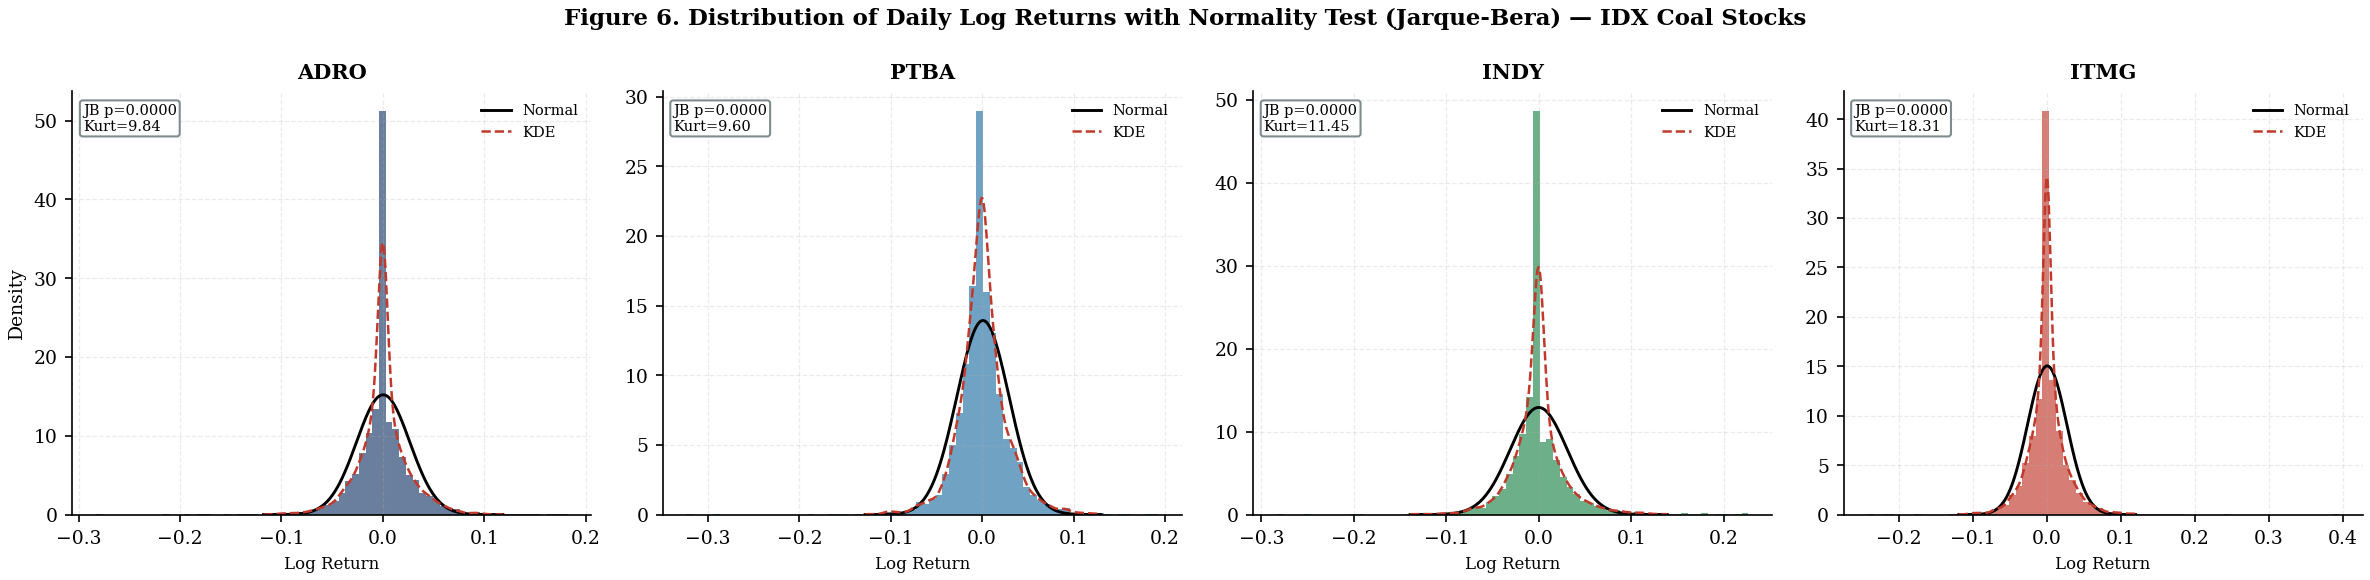

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, ticker, warna in zip(
    axes,
    ticker_list,
    warna_saham
):

    ret = df[f"ret_{ticker}"].dropna()

    ax.hist(
        ret,
        bins=70,
        color=warna,
        alpha=0.65,
        density=True,
        edgecolor="none"
    )

    mu, std = ret.mean(), ret.std()

    x_fit = np.linspace(
        mu - 4.5*std,
        mu + 4.5*std,
        300
    )

    ax.plot(
        x_fit,
        stats.norm.pdf(x_fit, mu, std),
        color="black",
        lw=1.4,
        label="Normal"
    )

    ax.plot(
        x_fit,
        stats.gaussian_kde(ret)(x_fit),
        color=C["red"],
        lw=1.2,
        ls="--",
        label="KDE"
    )

    jb_stat, jb_p = stats.jarque_bera(ret)

    ax.set_title(
        f"{ticker}",
        fontweight="bold",
        fontsize=10
    )

    ax.set_xlabel("Log Return", fontsize=8)

    ax.text(
        0.02,
        0.97,
        f"JB p={jb_p:.4f}\nKurt={stats.kurtosis(ret):.2f}",
        transform=ax.transAxes,
        fontsize=7,
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc="white",
            ec=C["gray"]
        )
    )

    if ax == axes[0]:
        ax.set_ylabel("Density", fontsize=9)

    ax.legend(
        frameon=False,
        fontsize=7,
        loc="upper right"
    )

fig.suptitle(
    "Figure 6. Distribution of Daily Log Returns with Normality Test (Jarque-Bera) — IDX Coal Stocks",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()

fig.savefig(
    f"{DIR_FIG}/fig06_return_distribusi.png",
    dpi=300
)

plt.show()

## 11. Statistik Deskriptif

Statistik deskriptif digunakan untuk memberikan gambaran umum mengenai karakteristik data saham yang meliputi nilai minimum, maksimum, rata-rata, standar deviasi, skewness, kurtosis, dan hasil uji normalitas.

In [13]:
harga_cols = ticker_list

stats_rows = []

for col in harga_cols:

    s = df[col]

    r = df[f"ret_{col}"].dropna()

    jb_stat, jb_p = stats.jarque_bera(r)

    stats_rows.append({
        "Emiten":             col,
        "Min (IDR)":          f"{s.min():.2f}",
        "Max (IDR)":          f"{s.max():.2f}",
        "Mean (IDR)":         f"{s.mean():.2f}",
        "Std (IDR)":          f"{s.std():.2f}",
        "Mean Return (%)":    f"{r.mean()*100:.4f}",
        "Std Return (%)":     f"{r.std()*100:.4f}",
        "Skewness":           f"{stats.skew(r):.4f}",
        "Kurtosis":           f"{stats.kurtosis(r):.4f}",
        "JB p-value":         f"{jb_p:.6f}",
        "Normal?":            "No" if jb_p < 0.05 else "Yes",
    })

tbl1 = pd.DataFrame(stats_rows)

tbl1.to_csv(
    f"{DIR_DATA}/tabel01_statistik_deskriptif.csv",
    index=False
)

display(tbl1)

,Emiten,Min (IDR),Max (IDR),Mean (IDR),Std (IDR),Mean Return (%),Std Return (%),Skewness,Kurtosis,JB p-value,Normal?
0,ADRO,88.47,2148.35,452.53,344.81,0.0347,2.6239,-0.0463,9.8418,0.000000,No
1,PTBA,23.42,2662.01,821.77,591.81,0.0828,2.8648,-0.2074,9.6024,0.000000,No
2,INDY,67.40,3079.85,1339.81,668.23,-0.0043,3.0909,1.0024,11.4478,0.000000,No
3,ITMG,877.15,26244.22,6904.77,5627.51,0.0402,2.6530,0.9214,18.3057,0.000000,No


## 12. Uji Stasioneritas ADF dan KPSS

Pengujian stasioneritas dilakukan menggunakan metode Augmented Dickey-Fuller (ADF) dan KPSS untuk menentukan apakah data time series sudah stasioner atau masih memerlukan proses differencing sebelum digunakan pada model forecasting.

In [14]:
def uji_stasioneritas(series, label):

    adf_res = adfuller(
        series.dropna(),
        autolag="AIC"
    )

    adf_stat = adf_res[0]
    adf_p    = adf_res[1]

    adf_cv1 = adf_res[4]["1%"]
    adf_cv5 = adf_res[4]["5%"]

    kpss_res = kpss(
        series.dropna(),
        regression="c",
        nlags="auto"
    )

    kpss_stat = kpss_res[0]
    kpss_p    = kpss_res[1]

    return {
        "Series":              label,
        "ADF Stat":            f"{adf_stat:.4f}",
        "ADF p-value":         f"{adf_p:.6f}",
        "ADF CV 1%":           f"{adf_cv1:.4f}",
        "ADF CV 5%":           f"{adf_cv5:.4f}",
        "ADF Result":          "Stationary" if adf_p < 0.05 else "Non-Stationary",
        "KPSS Stat":           f"{kpss_stat:.4f}",
        "KPSS p-value":        f"{'>{:.2f}'.format(kpss_p) if kpss_p > 0.1 else '<0.05'}",
        "KPSS Result":         "Non-Stationary" if kpss_stat > 0.463 else "Stationary",
        "Integration Order":   "",
    }

stat_rows = []

for ticker in ticker_list:

    r_level = uji_stasioneritas(
        df[ticker],
        f"{ticker} Level"
    )

    r_diff1 = uji_stasioneritas(
        df[ticker].diff().dropna(),
        f"{ticker} Δ¹"
    )

    r_logrt = uji_stasioneritas(
        df[f"ret_{ticker}"].dropna(),
        f"{ticker} Log Return"
    )

    if (
        r_level["ADF Result"] == "Non-Stationary"
        and
        r_diff1["ADF Result"] == "Stationary"
    ):

        r_level["Integration Order"] = "I(1)"

    elif r_level["ADF Result"] == "Stationary":

        r_level["Integration Order"] = "I(0)"

    stat_rows.extend([
        r_level,
        r_diff1,
        r_logrt
    ])

tbl2 = pd.DataFrame(stat_rows)

tbl2.to_csv(
    f"{DIR_DATA}/tabel02_uji_stasioneritas.csv",
    index=False
)

display(tbl2)

C:\Users\dayinta agustina\AppData\Local\Temp\ipykernel_28104\2363206706.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(


C:\Users\dayinta agustina\AppData\Local\Temp\ipykernel_28104\2363206706.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(


C:\Users\dayinta agustina\AppData\Local\Temp\ipykernel_28104\2363206706.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(


C:\Users\dayinta agustina\AppData\Local\Temp\ipykernel_28104\2363206706.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(


C:\Users\dayinta agustina\AppData\Local\Temp\ipykernel_28104\2363206706.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(


...

C:\Users\dayinta agustina\AppData\Local\Temp\ipykernel_28104\2363206706.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(


C:\Users\dayinta agustina\AppData\Local\Temp\ipykernel_28104\2363206706.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(


C:\Users\dayinta agustina\AppData\Local\Temp\ipykernel_28104\2363206706.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(


C:\Users\dayinta agustina\AppData\Local\Temp\ipykernel_28104\2363206706.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(


,Series,ADF Stat,ADF p-value,ADF CV 1%,ADF CV 5%,ADF Result,KPSS Stat,KPSS p-value,KPSS Result,Integration Order
0,ADRO Level,2.3420,0.998980,-3.4316,-2.8621,Non-Stationary,4.9195,<0.05,Non-Stationary,I(1)
1,ADRO Δ¹,-11.9144,0.000000,-3.4316,-2.8621,Stationary,0.7560,<0.05,Non-Stationary,
2,ADRO Log Return,-70.2494,0.000000,-3.4316,-2.8621,Stationary,0.2270,<0.05,Stationary,
3,PTBA Level,-0.4399,0.903229,-3.4316,-2.8621,Non-Stationary,8.0567,<0.05,Non-Stationary,I(1)
4,PTBA Δ¹,-13.4552,0.000000,-3.4316,-2.8621,Stationary,0.1009,<0.05,Stationary,
5,PTBA Log Return,-12.5069,0.000000,-3.4316,-2.8621,Stationary,0.2371,<0.05,Stationary,
6,INDY Level,-2.2511,0.188227,-3.4316,-2.8621,Non-Stationary,1.6820,<0.05,Non-Stationary,I(1)
7,INDY Δ¹,-13.1830,0.000000,-3.4316,-2.8621,Stationary,0.0654,<0.05,Stationary,
8,INDY Log Return,-11.1988,0.000000,-3.4316,-2.8621,Stationary,0.1139,<0.05,Stationary,
9,ITMG Level,0.3017,0.977421,-3.4316,-2.8621,Non-Stationary,5.5611,<0.05,Non-Stationary,I(1)
